In [1]:
import numpy as np
import matplotlib.pyplot as plt
k = 6
b = 7
n = 500
x = np.random.rand(n)
noise = np.random.randn(n)
y = k * x + b + noise

In [2]:
def least_squares(x, y):
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    num = np.sum((x - x_mean) * (y - y_mean))
    den = np.sum((x - x_mean) ** 2)
    k_est = num / den
    b_est = y_mean - k_est * x_mean
    return k_est, b_est
k_est, b_est = least_squares(x, y)
print(f"Estimated parameters using least squares: k = {k_est:.15f}, b = {b_est:.15f}")

Estimated parameters using least squares: k = 5.905230268614748, b = 6.983343265445439


In [3]:
k_np, b_np = np.polyfit(x, y, 1)
print(f"Estimated parameters using np.polyfit: k = {k_np:.15f}, b = {b_np:.15f}")

print(f"True parameters: k1 = {k}, b1 = {b}")
print(f"Difference (least squares): Δk1 = {abs(k_est - k):.15f}, Δb1 = {abs(b_est - b):.15f}")
print(f"Difference (np.polyfit): Δk1 = {abs(k_np - k):.15f}, Δb1 = {abs(b_np - b):.15f}")


Estimated parameters using np.polyfit: k = 5.905230268614748, b = 6.983343265445441
True parameters: k1 = 6, b1 = 7
Difference (least squares): Δk1 = 0.094769731385252, Δb1 = 0.016656734554561
Difference (np.polyfit): Δk1 = 0.094769731385252, Δb1 = 0.016656734554559


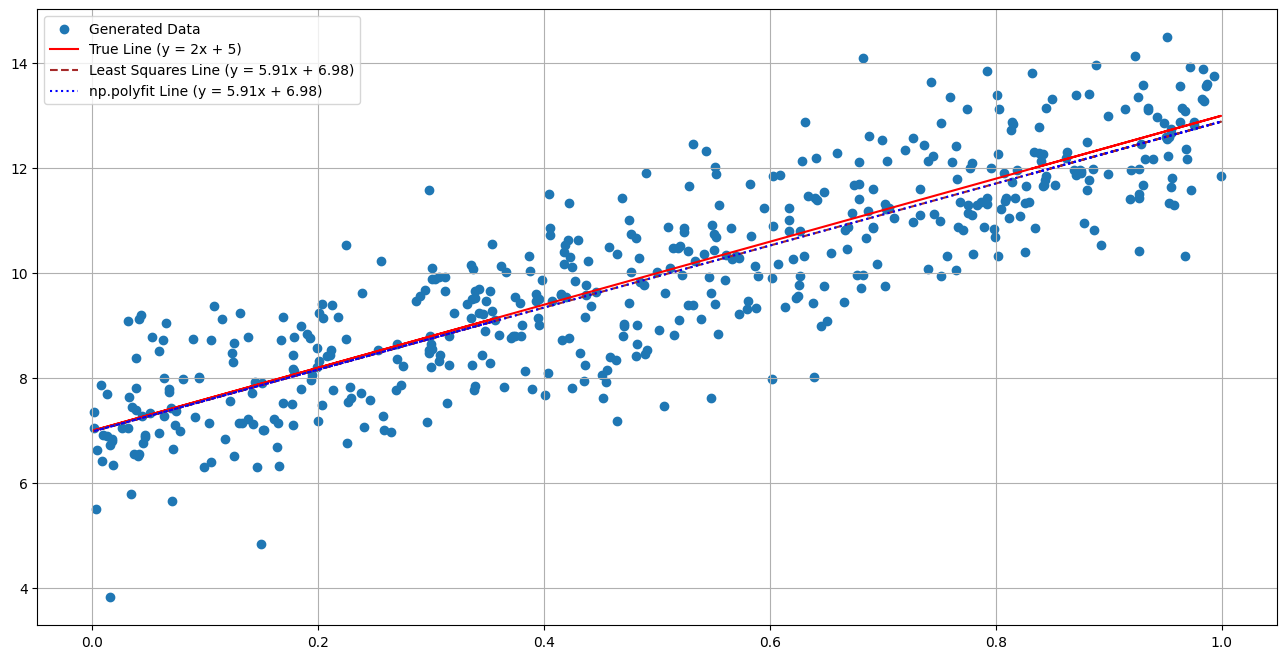

In [4]:
plt.figure(figsize=(16, 8))
plt.scatter(x, y, label='Generated Data')
plt.grid(visible=True)
plt.plot(x, k * x + b, color='red', label='True Line (y = 2x + 5)')
plt.plot(x, k_est * x + b_est, color='brown', linestyle='dashed', label=f'Least Squares Line (y = {k_est:.2f}x + {b_est:.2f})')
plt.plot(x, k_np * x + b_np, color='blue', linestyle='dotted', label=f'np.polyfit Line (y = {k_np:.2f}x + {b_np:.2f})')
plt.legend()
plt.show()

In [5]:
def gradient_descent(x, y, learning_rate=0.01, n_iter=1000):
    k = 0
    b = 0
    for i in range(n_iter):
        y_pred = k * x + b
        error = y - y_pred
        k_grad = -2 * np.mean(x * error)
        b_grad = -2 * np.mean(error)
        k -= learning_rate * k_grad
        b -= learning_rate * b_grad
    return k, b

learning_rate = 0.01
n_iter = 1000
k_gd, b_gd = gradient_descent(x, y, learning_rate, n_iter)
print(f"Estimated parameters using gradient descent: k = {k_gd:.2f}, b = {b_gd:.2f}")


Estimated parameters using gradient descent: k = 5.44, b = 7.23


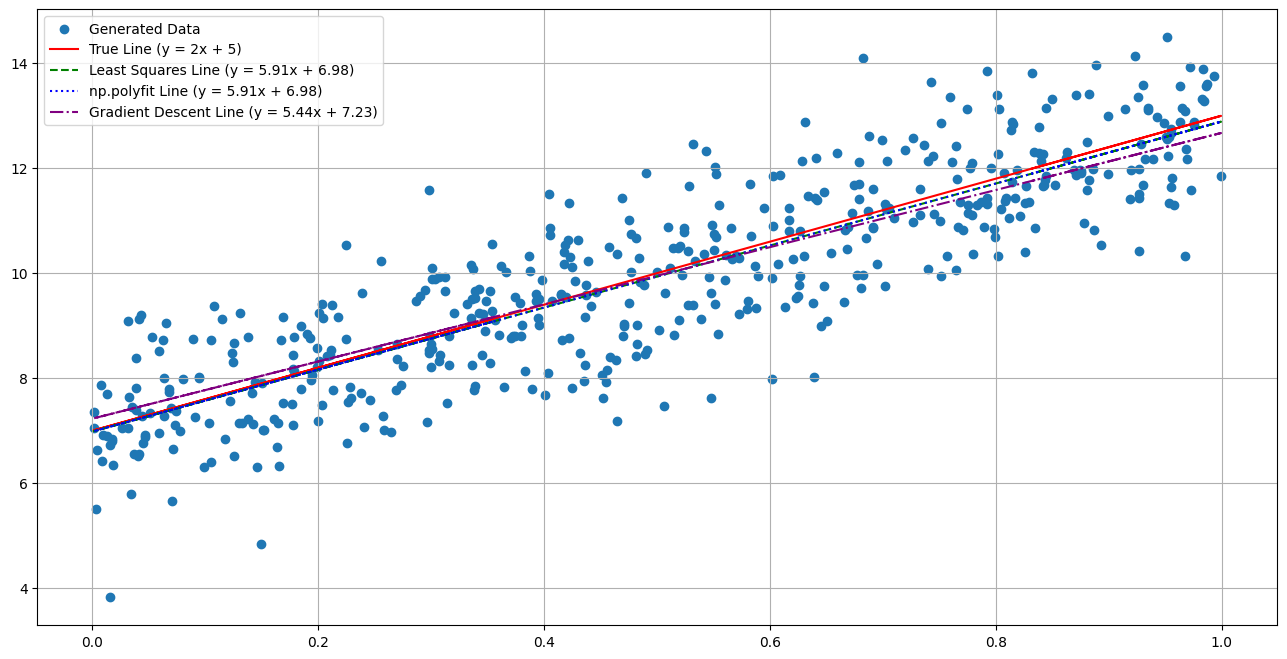

In [6]:
plt.figure(figsize=(16, 8))
plt.scatter(x, y, label='Generated Data')
plt.grid(visible=True)
plt.plot(x, k * x + b, color='red', label='True Line (y = 2x + 5)')
plt.plot(x, k_est * x + b_est, color='green', linestyle='dashed', label=f'Least Squares Line (y = {k_est:.2f}x + {b_est:.2f})')
plt.plot(x, k_np * x + b_np, color='blue', linestyle='dotted', label=f'np.polyfit Line (y = {k_np:.2f}x + {b_np:.2f})')
plt.plot(x, k_gd * x + b_gd, color='purple', linestyle='-.', label=f'Gradient Descent Line (y = {k_gd:.2f}x + {b_gd:.2f})')
plt.legend()
plt.show()

Gradient descent stopped early at iteration 124


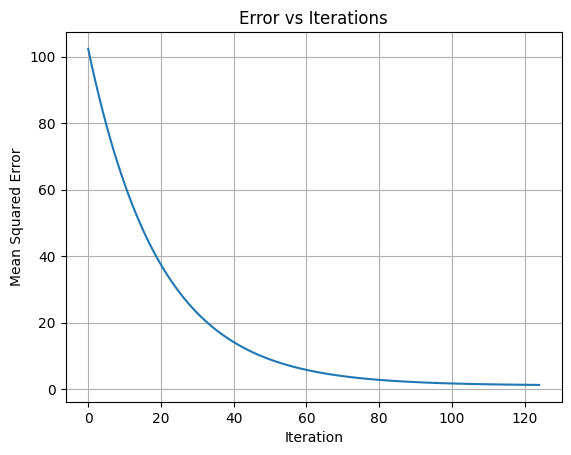

Minimum error achieved: 1.32


In [7]:
e=0.01
def gradient_descent_with_error(x, y, e, learning_rate=0.01, n_iter=1000):
    n = len(x)
    k = 0
    b = 0
    errors = []
    prev_mse = float('inf')
    for i in range(n_iter):
        y_pred = k * x + b
        error = y - y_pred
        k_grad = -2 * np.sum(x * error) / n
        b_grad = -2 * np.sum(error) / n
        k -= learning_rate * k_grad
        b -= learning_rate * b_grad
        mse = np.mean(error ** 2)
        errors.append(mse)
        if abs(prev_mse - mse) < e:
            print(f"Gradient descent stopped early at iteration {i}")
            break
        prev_mse = mse
    return k, b, errors

k_gd, b_gd, errors = gradient_descent_with_error(x, y, e, learning_rate, n_iter)
plt.plot(errors)
plt.grid(visible=True)
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Error vs Iterations')
plt.show()
min_error = min(errors)
print(f"Minimum error achieved: {min_error:.2f}")

In [8]:
print("Comparison of different methods:")
print(f"True parameters: k = {k}, b = {b}")
print(f"Least Squares: k = {k_est:.2f}, b = {b_est:.2f}, Δk = {abs(k_est - k):.2f}, Δb = {abs(b_est - b):.2f}")
print(f"np.polyfit: k = {k_np:.2f}, b = {b_np:.2f}, Δk = {abs(k_np - k):.2f}, Δb = {abs(b_np - b):.2f}")
print(f"Gradient Descent: k = {k_gd:.2f}, b = {b_gd:.2f}, Δk = {abs(k_gd - k):.2f}, Δb = {abs(b_gd - b):.2f}")

Comparison of different methods:
True parameters: k = 6, b = 7
Least Squares: k = 5.91, b = 6.98, Δk = 0.09, Δb = 0.02
np.polyfit: k = 5.91, b = 6.98, Δk = 0.09, Δb = 0.02
Gradient Descent: k = 4.29, b = 7.43, Δk = 1.71, Δb = 0.43
